# Q3: Retail sales regression pipeline

Target is items_sold. I use calendar effects, promotion plus store context, and a few engineered features inside one sklearn pipeline so preprocessing and modeling stay tied together.

In [29]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set(style="whitegrid")


In [31]:
df = pd.read_csv("../data/q3_retail_promotions.csv")
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


## Task 1: Date Feature Engineering


In [33]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek

# 1 if day of month >= 25, else 0
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

df[["transaction_date", "year", "month", "day_of_week", "is_month_end", "store_id", "items_sold"]].head()

,transaction_date,year,month,day_of_week,is_month_end,store_id,items_sold
0,2022-01-01,2022,1,5,0,28,224
1,2022-01-01,2022,1,5,0,5,348
2,2022-01-02,2022,1,6,0,13,249
3,2022-01-02,2022,1,6,0,17,259
4,2022-01-03,2022,1,0,0,50,277


## Time-aware split

I’m sorting by `transaction_date` and holding out the most recent 20% as test data so evaluation reflects real forecasting usage.

In [35]:
df = df.sort_values("transaction_date").reset_index(drop=True)

cut = int(len(df) * 0.8)
train_df = df.iloc[:cut].copy()
test_df = df.iloc[cut:].copy()

print("Train date range:", train_df["transaction_date"].min(), "to", train_df["transaction_date"].max())
print("Test date range: ", test_df["transaction_date"].min(), "to", test_df["transaction_date"].max())

X_train = train_df.drop(columns=["items_sold", "transaction_date"])
y_train = train_df["items_sold"]

X_test = test_df.drop(columns=["items_sold", "transaction_date"])
y_test = test_df["items_sold"]


Train date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range:  2024-06-12 00:00:00 to 2024-12-31 00:00:00


Random split would leak future patterns into training for this problem. That usually inflates offline metrics and gives a false sense of performance. A chronological split is stricter, but it mirrors production: train on past data, predict future periods.

## Task 3: Preprocessing Pipeline

We will use a ColumnTransformer inside a Pipeline:
- First One-hot encode promotion_type, location_type, and store_size
- Then Standard-scale all numerical features
- Finally, Fit preprocessing only on the training set, then apply it to both train/test

In [38]:
categorical_cols = ["promotion_type", "location_type", "store_size"]
categorical_cols = [c for c in categorical_cols if c in X_train.columns]

numerical_cols = [c for c in X_train.columns if c not in categorical_cols]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop")

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['promotion_type', 'location_type', 'store_size']
Numerical columns: ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


## Task 4: Model Training and Evaluation


In [39]:
linreg_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression()),
    ])
rf_pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(n_estimators=500, random_state=42)),
    ])
pipelines = {
    "Linear Regression": linreg_pipe,
    "Random Forest Regressor": rf_pipe}

results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_test, preds))

    results[name] = {"rmse": rmse, "mae": mae, "preds": preds, "model": pipe}

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE: ", mae)



Linear Regression
RMSE: 27.121451164890622
MAE:  21.052926674588395

Random Forest Regressor
RMSE: 30.62403956779706
MAE:  24.14149166666667


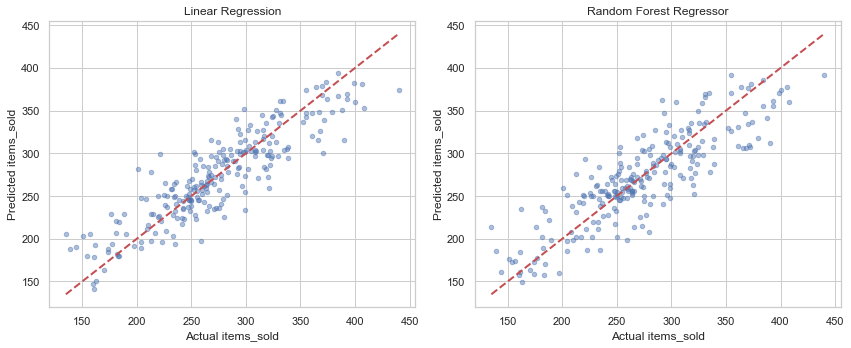

In [41]:
# Parity plots (predicted vs actual)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, res) in zip(axes, results.items()):
    y_pred = res["preds"]
    ax.scatter(y_test, y_pred, alpha=0.45, s=20)

    min_v = min(y_test.min(), y_pred.min())
    max_v = max(y_test.max(), y_pred.max())
    ax.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2)

    ax.set_title(name)
    ax.set_xlabel("Actual items_sold")
    ax.set_ylabel("Predicted items_sold")



plt.tight_layout()
plt.show()


In [43]:
# Feature importances from Random Forest
rf_pipe_fit = results["Random Forest Regressor"]["model"]
rf_model = rf_pipe_fit.named_steps["model"]
rf_preprocess = rf_pipe_fit.named_steps["preprocess"]
feature_names = rf_preprocess.get_feature_names_out()
importances = rf_model.feature_importances_

importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("\nTop 5 most influential features (Random Forest):")


print(importance_series.head(5).round(6))



Top 5 most influential features (Random Forest):
num__is_festival            0.176539
cat__store_size_small       0.163064
cat__location_type_urban    0.118231
num__day_of_week            0.083383
num__is_weekend             0.065191
dtype: float64
